# Higher-Order Gaussian Atom-Slice Corrections

This notebook focuses on atomic slice interactions. It plots a 9 x 9 gold atom-column patch, compares fitted-quadratic Gaussian propagation against a one-slice Fresnel reference after a longer free-space propagation distance, and records synchronized GPU/CPU timings for the Gaussian and Fresnel paths. It also keeps the single-atom center Taylor failure check as a minimal stress test.


## Setup

This notebook runs on the default JAX backend. If a CUDA backend is visible, the fitted Gaussian correction path can use the GPU; otherwise JAX falls back to CPU.


In [1]:
import os
import time

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.4")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import AtomicPotential, Detector
from temgym_core.evaluate import evaluate_gaussians_fast, evaluate_gaussians_for
from temgym_core.gaussian import (
    GaussianBeam,
    apply_action_delta,
    make_gaussian,
    propagate_free_space_jit,
    taylor_expand,
)
from temgym_core.gaussian_corrections import (
    apply_fitted_quadratic_action,
    split_gaussian_realspace,
)
from temgym_core.potential import potential_smoothed_from_r2
from temgym_core.source import square_input_wave
from temgym_core.utils import FresnelPropagator

jax.config.update("jax_enable_x64", True)
print("JAX backend:", jax.devices()[0].platform)


JAX backend: gpu


## Shared Helpers

In [2]:
# Lobato-Van Dyck neutral-atom coefficients for Au in the same 2 x 5
# parameter format as temgym_core.potential.Si. The values are from
# abTEM's lobato.json table.
Au = jnp.array(
    [
        [
            1.6759346706487,
            3.00486602969729,
            0.595340013161635,
            0.0117163186623094,
            4.296782976398e-05,
        ],
        [
            5.52231093211402,
            1.38007223007196,
            0.162229237655945,
            0.00901814890416575,
            0.00037927766747767,
        ],
    ],
    dtype=jnp.float64,
)

TIMING_STAGE_KEYS = (
    "input_eval",
    "fresnel_reference",
    "fit_gaussian_slice",
    "gaussian_propagate",
    "output_eval",
)


def block_until_ready(value):
    def block_leaf(x):
        return x.block_until_ready() if hasattr(x, "block_until_ready") else x

    return jax.tree_util.tree_map(block_leaf, value)


def timed_call(fn):
    t0 = time.perf_counter()
    value = fn()
    block_until_ready(value)
    return value, time.perf_counter() - t0


def add_derived_timings(timings):
    timings = dict(timings)
    timings["gaussian_path_total"] = (
        timings["fit_gaussian_slice"]
        + timings["gaussian_propagate"]
        + timings["output_eval"]
    )
    timings["full_case_total"] = sum(timings[key] for key in TIMING_STAGE_KEYS)
    return timings


def summarize_timing_records(records):
    stats = {}
    for key in records[0]:
        values = np.asarray([record[key] for record in records], dtype=float)
        stats[key] = {
            "min": float(np.min(values)),
            "median": float(np.median(values)),
            "mean": float(np.mean(values)),
        }
    return stats


def best_timings(stats):
    return {key: value["min"] for key, value in stats.items()}


def aligned_field_error(test, ref):
    alpha = jnp.vdot(test, ref) / jnp.vdot(test, test)
    return float(jnp.linalg.norm(alpha * test - ref) / jnp.linalg.norm(ref))


def normalized_intensity_error(test, ref):
    test_i = jnp.abs(test) ** 2
    ref_i = jnp.abs(ref) ** 2
    test_i = test_i / jnp.sum(test_i)
    ref_i = ref_i / jnp.sum(ref_i)
    return float(jnp.linalg.norm(test_i - ref_i) / jnp.linalg.norm(ref_i))


def evaluate_gaussian_field(
    beam,
    grid,
    *,
    method="auto",
    batch_size=128,
    tile_pixels=64,
    tile_beams=16,
):
    return evaluate_gaussians_fast(
        beam.to_vector(),
        grid,
        method=method,
        batch_size=batch_size,
        tile_pixels=tile_pixels,
        tile_beams=tile_beams,
    )


def multi_atom_action(xy, z, sigma, k, atom_xyz, dz, cutoff_radius, element_params):
    def one_atom(atom):
        r2 = (
            (xy[0] - atom[0]) ** 2
            + (xy[1] - atom[1]) ** 2
            + (z - atom[2]) ** 2
        )
        return potential_smoothed_from_r2(r2, element_params, cutoff_radius)

    potential = jnp.sum(jax.vmap(one_atom)(atom_xyz))
    return -(sigma / k) * potential * dz


def _apply_fitted_slice_to_vector(
    vector,
    atom_xyz,
    dz,
    cutoff_radius,
    element_params,
    fit_support_radius,
    fit_samples_per_axis,
):
    def one_ray(ray):
        return apply_fitted_quadratic_action(
            ray,
            lambda xy: multi_atom_action(
                xy,
                ray.z,
                ray.sigma,
                ray.k,
                atom_xyz,
                dz,
                cutoff_radius,
                element_params,
            ),
            fit_support_radius=fit_support_radius,
            fit_samples_per_axis=fit_samples_per_axis,
        )

    return jax.vmap(one_ray)(vector)


_apply_fitted_slice_to_vector = jax.jit(
    _apply_fitted_slice_to_vector,
    static_argnames=("fit_support_radius", "fit_samples_per_axis"),
)


def apply_fitted_slice_to_bundle(
    beam: GaussianBeam,
    atom_xyz,
    dz,
    cutoff_radius,
    element_params,
    *,
    fit_support_radius=1.0,
    fit_samples_per_axis=5,
):
    return _apply_fitted_slice_to_vector(
        beam.to_vector(),
        atom_xyz,
        dz,
        cutoff_radius,
        element_params,
        fit_support_radius,
        fit_samples_per_axis,
    )


def _reference_atom_slice_field_eager(
    input_field,
    coords,
    pixel_size,
    wavelength,
    atom_xyz,
    sigma,
    k,
    dz,
    cutoff_radius,
    propagation,
    element_params,
):
    action = jax.vmap(
        lambda xy: multi_atom_action(
            xy, 0.0, sigma, k, atom_xyz, dz, cutoff_radius, element_params
        )
    )(coords).reshape(input_field.shape)
    transmitted = input_field * jnp.exp(1j * k * action)
    return FresnelPropagator(
        transmitted,
        L=pixel_size * input_field.shape[0],
        wavelength=wavelength,
        z=propagation,
    )


_reference_atom_slice_field_jit = jax.jit(_reference_atom_slice_field_eager)
reference_jit_enabled = os.environ.get("TEMGYM_REFERENCE_JIT", "1") != "0"


def reference_atom_slice_field(
    input_field,
    grid,
    wavelength,
    atom_xyz,
    sigma,
    k,
    dz,
    cutoff_radius,
    propagation,
    element_params,
):
    global reference_jit_enabled
    args = (
        input_field,
        grid.coords,
        grid.pixel_size[0],
        wavelength,
        atom_xyz,
        sigma,
        k,
        dz,
        cutoff_radius,
        propagation,
        element_params,
    )
    if reference_jit_enabled:
        try:
            return _reference_atom_slice_field_jit(*args)
        except Exception as exc:
            message = str(exc).lower()
            if "resource_exhausted" not in message and "out of memory" not in message:
                raise
            reference_jit_enabled = False
            print("Reference JIT ran out of GPU memory; using eager reference timing.")
    return _reference_atom_slice_field_eager(*args)


def run_atom_slice_pipeline(
    beam,
    grid,
    atom_xyz,
    dz,
    cutoff_radius,
    propagation,
    element_params,
    *,
    fit_support_radius=1.0,
    fit_samples_per_axis=5,
    eval_method="auto",
    eval_batch_size=128,
    eval_tile_pixels=64,
    eval_tile_beams=16,
):
    vector = beam.to_vector()
    wavelength = vector.wavelength[0]
    sigma = vector.sigma[0]
    k = vector.k[0]

    input_field, t_input = timed_call(
        lambda: evaluate_gaussian_field(
            beam,
            grid,
            method=eval_method,
            batch_size=eval_batch_size,
            tile_pixels=eval_tile_pixels,
            tile_beams=eval_tile_beams,
        )
    )
    reference, t_reference = timed_call(
        lambda: reference_atom_slice_field(
            input_field,
            grid,
            wavelength,
            atom_xyz,
            sigma,
            k,
            dz,
            cutoff_radius,
            propagation,
            element_params,
        )
    )
    fitted, t_fit = timed_call(
        lambda: apply_fitted_slice_to_bundle(
            beam,
            atom_xyz,
            dz,
            cutoff_radius,
            element_params,
            fit_support_radius=fit_support_radius,
            fit_samples_per_axis=fit_samples_per_axis,
        )
    )
    propagated, t_propagate = timed_call(
        lambda: propagate_free_space_jit(fitted, propagation)
    )
    gaussian, t_output = timed_call(
        lambda: evaluate_gaussian_field(
            propagated,
            grid,
            method=eval_method,
            batch_size=eval_batch_size,
            tile_pixels=eval_tile_pixels,
            tile_beams=eval_tile_beams,
        )
    )

    timings = add_derived_timings(
        {
            "input_eval": t_input,
            "fresnel_reference": t_reference,
            "fit_gaussian_slice": t_fit,
            "gaussian_propagate": t_propagate,
            "output_eval": t_output,
        }
    )
    outputs = {
        "input": input_field,
        "reference": reference,
        "gaussian": gaussian,
    }
    return outputs, timings


def run_atom_slice_case(
    name,
    beam,
    grid,
    atom_xyz,
    dz,
    cutoff_radius,
    propagation,
    element_params,
    *,
    fit_support_radius=1.0,
    fit_samples_per_axis=5,
    eval_method="auto",
    eval_batch_size=128,
    eval_tile_pixels=64,
    eval_tile_beams=16,
    benchmark_repeats=3,
):
    vector = beam.to_vector()
    outputs, timings = run_atom_slice_pipeline(
        beam,
        grid,
        atom_xyz,
        dz,
        cutoff_radius,
        propagation,
        element_params,
        fit_support_radius=fit_support_radius,
        fit_samples_per_axis=fit_samples_per_axis,
        eval_method=eval_method,
        eval_batch_size=eval_batch_size,
        eval_tile_pixels=eval_tile_pixels,
        eval_tile_beams=eval_tile_beams,
    )

    warm_records = []
    for _ in range(benchmark_repeats):
        _, warm_timings = run_atom_slice_pipeline(
            beam,
            grid,
            atom_xyz,
            dz,
            cutoff_radius,
            propagation,
            element_params,
            fit_support_radius=fit_support_radius,
            fit_samples_per_axis=fit_samples_per_axis,
            eval_method=eval_method,
            eval_batch_size=eval_batch_size,
            eval_tile_pixels=eval_tile_pixels,
            eval_tile_beams=eval_tile_beams,
        )
        warm_records.append(warm_timings)

    warm_stats = summarize_timing_records(warm_records) if warm_records else {}
    warm_timings = best_timings(warm_stats) if warm_stats else timings

    result = {
        "name": name,
        "beams": int(np.asarray(vector.x).size),
        "field_error": aligned_field_error(outputs["gaussian"], outputs["reference"]),
        "intensity_error": normalized_intensity_error(
            outputs["gaussian"], outputs["reference"]
        ),
        "timings": timings,
        "warm_timings": warm_timings,
        "warm_timing_stats": warm_stats,
        "eval_method": eval_method,
        **outputs,
    }
    print(
        f"{name}: beams={result['beams']}, "
        f"field_error={result['field_error']:.4g}, "
        f"intensity_error={result['intensity_error']:.4g}, "
        f"first_gaussian_path={timings['gaussian_path_total']:.2f}s, "
        f"warm_gaussian_path={warm_timings['gaussian_path_total']:.3f}s, "
        f"warm_reference={warm_timings['fresnel_reference']:.3f}s"
    )
    return result


def show_case(result, extent):
    reference = np.asarray(result["reference"])
    gaussian = np.asarray(result["gaussian"])
    diff = np.abs(gaussian) ** 2 - np.abs(reference) ** 2

    fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
    images = [
        (np.abs(reference), "Fresnel amplitude", "inferno"),
        (np.abs(gaussian), "Gaussian amplitude", "inferno"),
        (diff, "Intensity difference", "coolwarm"),
        (np.angle(reference), "Fresnel phase", "twilight"),
        (np.angle(gaussian), "Gaussian phase", "twilight"),
        (np.angle(gaussian * np.conj(reference)), "Relative phase", "twilight"),
    ]
    for ax, (data, title, cmap) in zip(axes.ravel(), images):
        im = ax.imshow(data, extent=extent, origin="lower", cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel("x (A)")
        ax.set_ylabel("y (A)")
        fig.colorbar(im, ax=ax, shrink=0.75)
    fig.suptitle(result["name"])
    fig.tight_layout()
    return fig


## 1. Gold Atom Plane: Fitted Gaussian Slice vs Grid Reference

The main diagnostic now uses a 9 x 9 Au(001)-like atom-column patch with nearest-neighbour spacing `a / sqrt(2)` from the fcc gold lattice constant. The reference is a one-slice grid transmission followed by Fresnel propagation over a longer distance, while the Gaussian path fits a local quadratic action over each Gaussian support and then propagates the resulting bundle analytically.


In [3]:
voltage = 200e3
au_lattice_constant = 4.078  # angstrom, room-temperature fcc Au
au_column_spacing = au_lattice_constant / np.sqrt(2.0)
n_atoms_side = 9
extent = 0.5 * (n_atoms_side - 1) * au_column_spacing + 5.0  # angstrom half-width
n_px = 160
dz = 0.02  # angstrom slice thickness
propagation = 80.0  # angstrom free-space propagation after the slice
pixel = 2 * extent / n_px
cutoff_radius = pixel / 3.0
fit_samples_per_axis = 5

grid = Detector(z=0.0, pixel_size=(pixel, pixel), shape=(n_px, n_px))
plot_extent = (grid.extent[0], grid.extent[1], grid.extent[2], grid.extent[3])

axis = (jnp.arange(n_atoms_side, dtype=jnp.float64) - 0.5 * (n_atoms_side - 1)) * au_column_spacing
xx, yy = jnp.meshgrid(axis, axis, indexing="ij")
atom_xyz = jnp.stack(
    (xx.ravel(), yy.ravel(), jnp.zeros((n_atoms_side * n_atoms_side,), dtype=jnp.float64)),
    axis=-1,
)

tem_beam = square_input_wave(
    aperture_length=2 * extent,
    waist=2.4,
    voltage=voltage,
    overlap_factor=1.1,
    wavelength_unit="angstrom",
)

stem_parent = make_gaussian(
    x=0.0,
    y=0.0,
    z=0.0,
    voltage=voltage,
    waist_x=1.0,
    waist_y=1.0,
    wavelength_unit="angstrom",
)
stem_probe = split_gaussian_realspace(
    stem_parent,
    grid_shape=(5, 5),
    support_radius=1.2,
    child_width_scale=0.55,
    fit_samples_per_axis=7,
)

print(f"Au atom columns: {atom_xyz.shape[0]}")
print(f"Grid: {grid.shape}, pixel={pixel:.3f} A, propagation={propagation:.1f} A")
print(f"TEM beams: {np.asarray(tem_beam.to_vector().x).size}")
print(f"STEM split beams: {np.asarray(stem_probe.to_vector().x).size}")

atom_results = {
    "TEM": run_atom_slice_case(
        "TEM-like broad beam on 9 x 9 Au patch",
        tem_beam,
        grid,
        atom_xyz,
        dz,
        cutoff_radius,
        propagation,
        Au,
        fit_samples_per_axis=fit_samples_per_axis,
    ),
    "STEM": run_atom_slice_case(
        "STEM-like split probe on central Au column",
        stem_probe,
        grid,
        atom_xyz,
        dz,
        cutoff_radius,
        propagation,
        Au,
        fit_samples_per_axis=fit_samples_per_axis,
    ),
}


Au atom columns: 81
Grid: (160, 160), pixel=0.207 A, propagation=80.0 A
TEM beams: 256
STEM split beams: 25
TEM-like broad beam on 9 x 9 Au patch: beams=256, field_error=0.01928, intensity_error=0.01753, first_gaussian_path=4.31s, warm_gaussian_path=0.023s, warm_reference=0.016s
STEM-like split probe on central Au column: beams=25, field_error=0.0002095, intensity_error=0.0001433, first_gaussian_path=2.77s, warm_gaussian_path=0.026s, warm_reference=0.019s


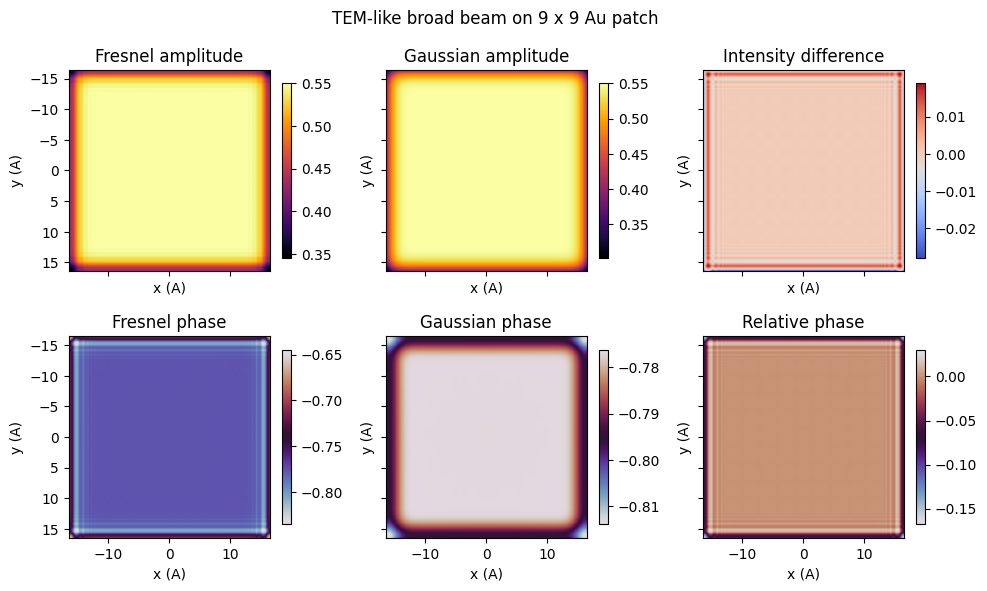

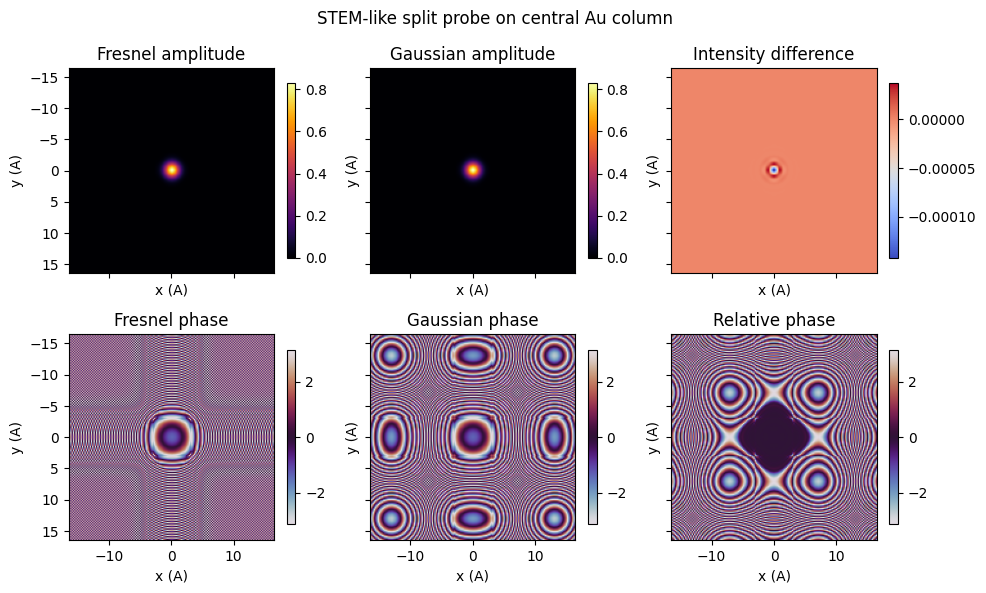

In [4]:
show_case(atom_results["TEM"], plot_extent)
show_case(atom_results["STEM"], plot_extent)
plt.show()

## Atom Potential And Thin-Slice Phase

This shows the scalar potential used for the 9 x 9 Au atom-column patch and the corresponding thin-slice phase shift for the TEM/STEM comparison above.


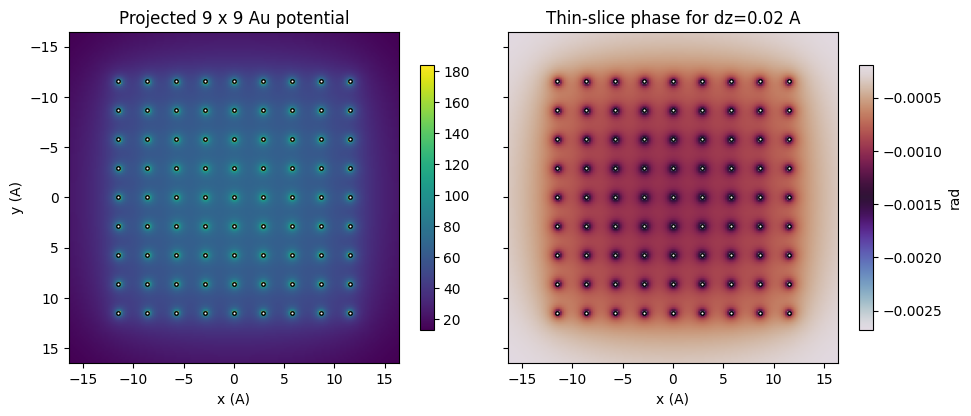

In [5]:
def atom_plane_potential(coords, atom_xyz, cutoff_radius, element_params):
    def value_at_xy(xy):
        def one_atom(atom):
            r2 = (xy[0] - atom[0]) ** 2 + (xy[1] - atom[1]) ** 2 + atom[2] ** 2
            return potential_smoothed_from_r2(r2, element_params, cutoff_radius)

        return jnp.sum(jax.vmap(one_atom)(atom_xyz))

    return jax.vmap(value_at_xy)(coords).reshape(grid.shape)


potential_map = atom_plane_potential(grid.coords, atom_xyz, cutoff_radius, Au)
tem_vector = tem_beam.to_vector()
slice_action = jax.vmap(
    lambda xy: multi_atom_action(
        xy,
        0.0,
        tem_vector.sigma[0],
        tem_vector.k[0],
        atom_xyz,
        dz,
        cutoff_radius,
        Au,
    )
)(grid.coords).reshape(grid.shape)
phase_map = tem_vector.k[0] * slice_action
block_until_ready((potential_map, phase_map))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
im0 = axes[0].imshow(np.asarray(potential_map), extent=plot_extent, origin="lower")
axes[0].plot(np.asarray(atom_xyz[:, 0]), np.asarray(atom_xyz[:, 1]), "wo", ms=2.5, mec="k")
axes[0].set_title("Projected 9 x 9 Au potential")
axes[0].set_xlabel("x (A)")
axes[0].set_ylabel("y (A)")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(np.asarray(phase_map), extent=plot_extent, origin="lower", cmap="twilight")
axes[1].plot(np.asarray(atom_xyz[:, 0]), np.asarray(atom_xyz[:, 1]), "wo", ms=2.5, mec="k")
axes[1].set_title(f"Thin-slice phase for dz={dz} A")
axes[1].set_xlabel("x (A)")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="rad")

fig.tight_layout()
plt.show()


## Propagated Gaussian Fields vs Fresnel Reference

These line profiles are taken after the fitted Gaussian slice interaction and the same longer free-space propagation distance used by the Fresnel reference. The center line crosses the middle row of Au columns, making the interference fringes easier to compare.


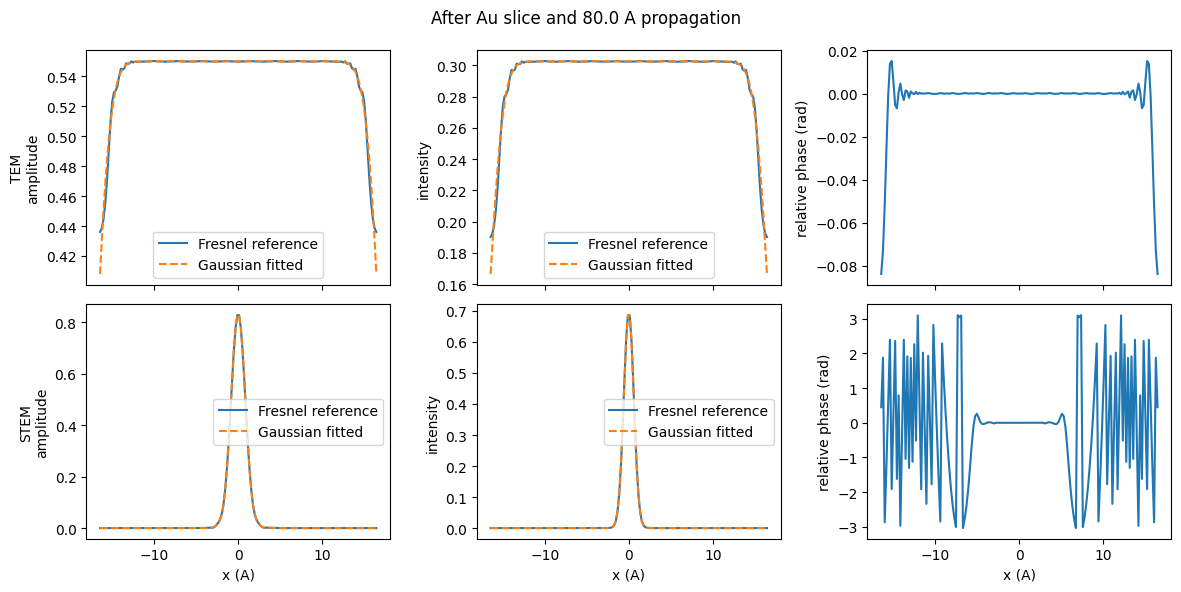

In [6]:
x_coords = np.asarray(grid.coords_1d[0])
center_y = grid.shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for row, key in enumerate(["TEM", "STEM"]):
    result = atom_results[key]
    reference = np.asarray(result["reference"])
    gaussian = np.asarray(result["gaussian"])
    reference_intensity = np.abs(reference[center_y, :]) ** 2
    gaussian_intensity = np.abs(gaussian[center_y, :]) ** 2

    axes[row, 0].plot(x_coords, np.abs(reference[center_y, :]), label="Fresnel reference")
    axes[row, 0].plot(x_coords, np.abs(gaussian[center_y, :]), "--", label="Gaussian fitted")
    axes[row, 0].set_ylabel(f"{key}\namplitude")

    axes[row, 1].plot(x_coords, reference_intensity, label="Fresnel reference")
    axes[row, 1].plot(x_coords, gaussian_intensity, "--", label="Gaussian fitted")
    axes[row, 1].set_ylabel("intensity")

    relative_phase = np.angle(gaussian[center_y, :] * np.conj(reference[center_y, :]))
    axes[row, 2].plot(x_coords, relative_phase)
    axes[row, 2].set_ylabel("relative phase (rad)")

for ax in axes[-1, :]:
    ax.set_xlabel("x (A)")
for ax in axes[:, :2].ravel():
    ax.legend()

fig.suptitle(f"After Au slice and {propagation} A propagation")
fig.tight_layout()
plt.show()


## Timing Cost

The first complete run includes JAX and Pallas compilation. Each case also reruns the same staged pipeline several times and reports the best warm timing, which is the useful number for comparing the steady-state Gaussian path against the FFT/Fresnel reference.


If the GPU is already heavily occupied, set `TEMGYM_REFERENCE_JIT=0` before starting the kernel to skip the larger compiled reference and keep the Gaussian GPU benchmark runnable.



TEM (256 beams, eval=auto)
  First run, including compile where applicable
    Input Gaussian eval   :    1.389 s
    Fresnel reference     :    4.121 s
    Fit Gaussian slice    :    3.891 s
    Gaussian propagate    :    0.363 s
    Output Gaussian eval  :    0.057 s
    Gaussian path total   :    4.311 s
    Full case total       :    9.821 s
  Warm best-of-repeat timing
    Input Gaussian eval   :   0.0198 s (median   0.0253 s)
    Fresnel reference     :   0.0161 s (median   0.0202 s)
    Fit Gaussian slice    :   0.0023 s (median   0.0025 s)
    Gaussian propagate    :   0.0009 s (median   0.0009 s)
    Output Gaussian eval  :   0.0200 s (median   0.0250 s)
    Gaussian path total   :   0.0232 s
    Full case total       :   0.0592 s

STEM (25 beams, eval=auto)
  First run, including compile where applicable
    Input Gaussian eval   :    0.835 s
    Fresnel reference     :    0.017 s
    Fit Gaussian slice    :    2.372 s
    Gaussian propagate    :    0.370 s
    Output Gaussi

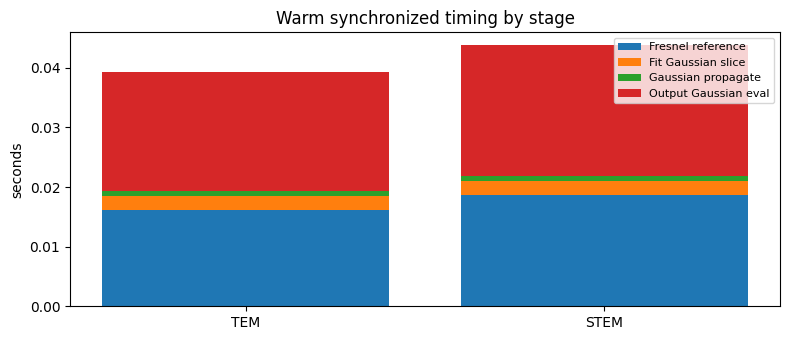

In [7]:
timing_labels = {
    "input_eval": "Input Gaussian eval",
    "fresnel_reference": "Fresnel reference",
    "fit_gaussian_slice": "Fit Gaussian slice",
    "gaussian_propagate": "Gaussian propagate",
    "output_eval": "Output Gaussian eval",
}

for key, result in atom_results.items():
    print(f"\n{key} ({result['beams']} beams, eval={result['eval_method']})")
    print("  First run, including compile where applicable")
    for timing_key, label in timing_labels.items():
        print(f"    {label:22s}: {result['timings'][timing_key]:8.3f} s")
    print(f"    {'Gaussian path total':22s}: {result['timings']['gaussian_path_total']:8.3f} s")
    print(f"    {'Full case total':22s}: {result['timings']['full_case_total']:8.3f} s")

    print("  Warm best-of-repeat timing")
    for timing_key, label in timing_labels.items():
        stats = result['warm_timing_stats'][timing_key]
        print(
            f"    {label:22s}: {stats['min']:8.4f} s "
            f"(median {stats['median']:8.4f} s)"
        )
    print(f"    {'Gaussian path total':22s}: {result['warm_timings']['gaussian_path_total']:8.4f} s")
    print(f"    {'Full case total':22s}: {result['warm_timings']['full_case_total']:8.4f} s")

stage_order = ["fresnel_reference", "fit_gaussian_slice", "gaussian_propagate", "output_eval"]
fig, ax = plt.subplots(figsize=(8, 3.5))
case_names = list(atom_results.keys())
bottom = np.zeros(len(case_names))
for stage in stage_order:
    values = np.array([atom_results[key]["warm_timings"][stage] for key in case_names])
    ax.bar(case_names, values, bottom=bottom, label=timing_labels[stage])
    bottom += values
ax.set_ylabel("seconds")
ax.set_title("Warm synchronized timing by stage")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## 2. Single Au Atom: Center Taylor vs Fitted Quadratic

This cell isolates the atom-core effect for a single gold atom. A Gaussian centered exactly on the atom is a bad case for derivative Taylor expansion, but sampled fitted quadratics handle it well.


Taylor field error: 0.8042843718594311
Fitted field error: 0.0009093056209963252


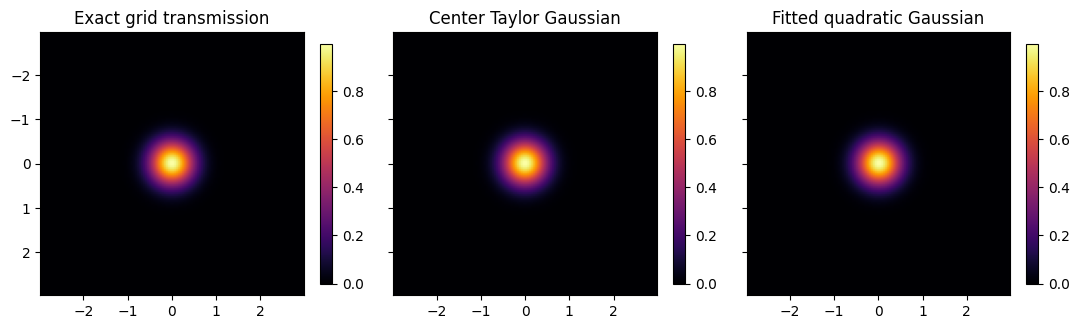

In [8]:
single_extent = 3.0
single_n = 128
single_pixel = 2 * single_extent / single_n
single_grid = Detector(
    z=0.0,
    pixel_size=(single_pixel, single_pixel),
    shape=(single_n, single_n),
)
single_atom = AtomicPotential(
    atom_xyz=jnp.array([0.0, 0.0, 0.0]),
    element_params=Au,
    cutoff_radius=single_pixel / 3.0,
    z=0.0,
)
single_ray = make_gaussian(
    x=0.0,
    y=0.0,
    z=0.0,
    voltage=voltage,
    waist_x=0.5,
    waist_y=0.5,
    wavelength_unit="angstrom",
)
single_dz = dz


def taylor_atom_kick(ray, atom, dz):
    dS0, dS1, dS2 = taylor_expand(atom.complex_action, ray.r_xy, ray.z, ray.sigma, ray.k)
    r_xy, d_xy, amplitude, pathlength, q_inv = apply_action_delta(
        ray, dS0=dS0 * dz, dS1=dS1 * dz, dS2=dS2 * dz
    )
    return ray.derive(
        x=r_xy[0],
        y=r_xy[1],
        dx=d_xy[0],
        dy=d_xy[1],
        amplitude=amplitude,
        pathlength=pathlength,
        Q_inv=q_inv,
    )


sigma = single_ray.sigma
k = single_ray.k
phase_grid = jax.vmap(single_atom.phase_shift, in_axes=(0, None, None, None))(
    single_grid.coords, 0.0, sigma, k
).reshape(single_grid.shape)
single_input = evaluate_gaussians_for(single_ray, single_grid)
single_reference = single_input * jnp.exp(1j * k * phase_grid * single_dz)

single_taylor = evaluate_gaussians_for(
    taylor_atom_kick(single_ray, single_atom, single_dz), single_grid
)
single_fitted_ray = apply_fitted_quadratic_action(
    single_ray,
    lambda xy: single_atom.complex_action(xy, single_ray.z, single_ray.sigma, single_ray.k)
    * single_dz,
    fit_support_radius=1.0,
    fit_samples_per_axis=7,
)
single_fitted = evaluate_gaussians_for(single_fitted_ray, single_grid)
block_until_ready((single_reference, single_taylor, single_fitted))

print("Taylor field error:", aligned_field_error(single_taylor, single_reference))
print("Fitted field error:", aligned_field_error(single_fitted, single_reference))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True, sharey=True)
for ax, field, title in [
    (axes[0], single_reference, "Exact grid transmission"),
    (axes[1], single_taylor, "Center Taylor Gaussian"),
    (axes[2], single_fitted, "Fitted quadratic Gaussian"),
]:
    im = ax.imshow(np.abs(field), extent=single_grid.extent, origin="lower", cmap="inferno")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.tight_layout()
plt.show()
